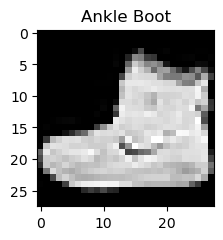

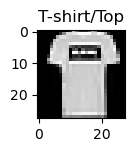

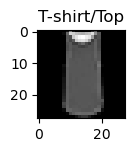

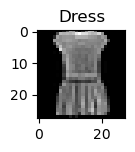

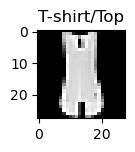

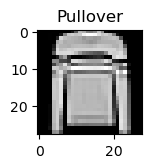

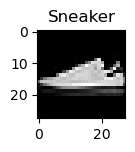

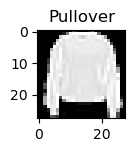

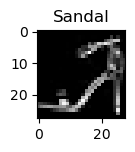

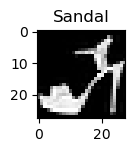

Data is successfully loaded
Shape of training data: (60000, 28, 28)


In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#1. Fashion-MNIST
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
#2. To analyze data 
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
#clothes name
class_names = ["T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]
#first 10 images show kare
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train_full[i],cmap='gray')
    plt.title(class_names[y_train_full[i]])
    plt.tight_layout()
    plt.show()
print("Data is successfully loaded")
print("Shape of training data:", X_train_full.shape)

In [2]:
#3. Neural network (Model)
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(50, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])
model.summary()
#compile model
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
#4. model ko 10 epochs
history = model.fit(X_train_full, y_train_full, epochs=10, validation_split=0.2)

C:\Users\Niyati Reshmi\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 271,160 (1.03 MB)

 Trainable params: 271,160 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8176 - loss: 0.5067 - val_accuracy: 0.8453 - val_loss: 0.4128
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8605 - loss: 0.3769 - val_accuracy: 0.8649 - val_loss: 0.3670
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8755 - loss: 0.3380 - val_accuracy: 0.8763 - val_loss: 0.3496
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8820 - loss: 0.3161 - val_accuracy: 0.8793 - val_loss: 0.3396
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8888 - loss: 0.2970 - val_accuracy: 0.8819 - val_loss: 0.3233
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8946 - loss: 0.2779 - val_accuracy: 0.8854 - val_loss: 0.3212
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9000 - loss: 0.2675 - val_accuracy: 0.8873 - val_loss: 0.3200
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9036 - loss: 0.2541 

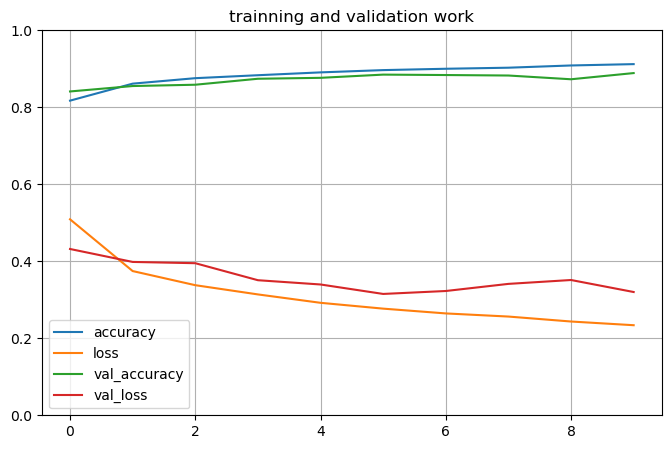

In [6]:
#5. graph plot
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("trainning and validation work")
plt.show()

In [3]:
#7 dropout
model_dropout = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(50, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
#model summary
model.summary()
model_dropout.compile(loss="sparse_categorical_crossentropy",
                      optimizer="adam",
                      metrics=["accuracy"])

history_dropout = model_dropout.fit(X_train_full, y_train_full, epochs=10, validation_split=0.2)
    

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,482 (3.10 MB)

 Trainable params: 271,160 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 542,322 (2.07 MB)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7740 - loss: 0.6298 - val_accuracy: 0.8480 - val_loss: 0.4280
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8369 - loss: 0.4529 - val_accuracy: 0.8583 - val_loss: 0.3855
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8482 - loss: 0.4164 - val_accuracy: 0.8637 - val_loss: 0.3677
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8578 - loss: 0.3918 - val_accuracy: 0.8733 - val_loss: 0.3590
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8616 - loss: 0.3762 - val_accuracy: 0.8668 - val_loss: 0.3642
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8685 - loss: 0.3647 - val_accuracy: 0.8752 - val_loss: 0.3468
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8719 - loss: 0.3504 - val_accuracy: 0.8723 - val_loss: 0.3408
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8731 - loss: 0.3446 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


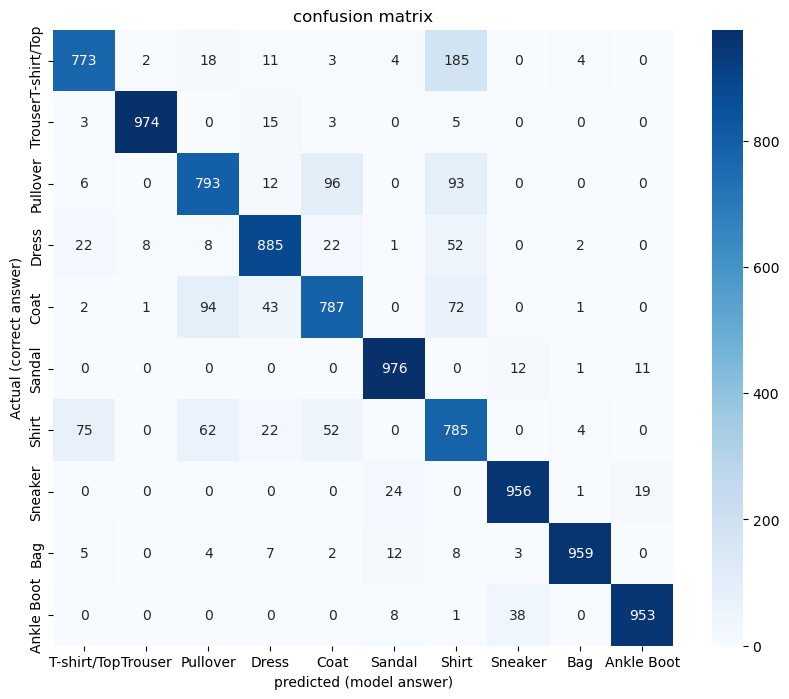

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_all = np.argmax(model.predict(X_test), axis=-1)

cm = confusion_matrix(y_test, y_pred_all)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual (correct answer)')
plt.xlabel('predicted (model answer)')
plt.title("confusion matrix")
plt.show()

In [12]:
X_new = X_test[:10]
y_proba = model.predict(X_new)
y_pred = np.argmax(y_proba, axis=-1)
print("prediction of model: ", [class_names[i] for i in y_pred])
print("real (right) kapra:", [class_names[i] for i in y_test[:10]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
prediction of model:  ['Ankle Boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser', 'Coat', 'Shirt', 'Sandal', 'Sneaker']
real (right) kapra: ['Ankle Boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser', 'Coat', 'Shirt', 'Sandal', 'Sneaker']
